In [2]:
import pandas as pd

# 전체 시트 확인
excel_file = pd.ExcelFile("skin_irritation.xlsx")
print("시트명:", excel_file.sheet_names)

# 첫 번째 시트 열어보고 컬럼명 확인
df = pd.read_excel("skin_irritation.xlsx", sheet_name=0)
print("\n컬럼명:")
print(df.columns.tolist()[:20])  # 처음 20개만
print("\n샘플 데이터:")
print(df.head(3))

시트명: ['Metadata', 'Data_invitro', 'Data_invivo']

컬럼명:
['ICE version:', '4.1']

샘플 데이터:
    ICE version:          4.1
0  File created:   2024-07-25
1            NaN          NaN
2         Column  Description


In [3]:
import pandas as pd
import numpy as np

# In vivo 데이터 시트 불러오기 (Human 데이터는 보통 여기)
df = pd.read_excel("skin_irritation.xlsx", sheet_name="Data_invivo")

print("컬럼명:", df.columns.tolist())
print("\n데이터 크기:", df.shape)
print("\nHuman 데이터 확인:")
print(df["Species"].value_counts().head())
print("\nPositive reaction 데이터 확인:")
print(df[df["Endpoint"].str.contains("Positive reaction", na=False, case=False)].shape)

컬럼명: ['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Concentration', 'Concentration_Units', 'Mixture', 'Species', 'Reported_Strain', 'Strain', 'Sex', 'Assay', 'Endpoint', 'Response', 'Response_Unit', 'Reference', 'SMILES', 'Preferred_Name', 'Synonyms', 'URL_CompTox', 'URL_CEBS']

데이터 크기: (2058, 25)

Human 데이터 확인:
Species
Rabbit    1878
Human      180
Name: count, dtype: int64

Positive reaction 데이터 확인:
(90, 25)


C:\Users\DS\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\DS\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


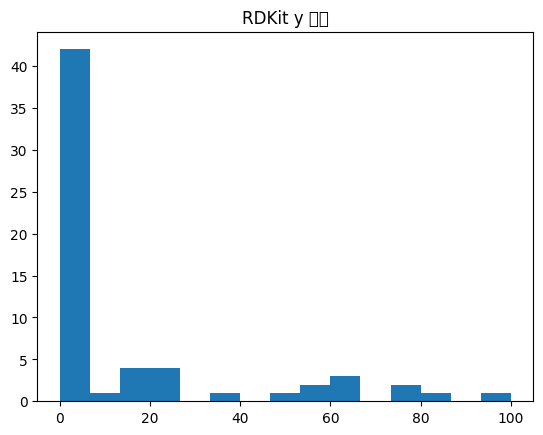

90→62행, SMILES: 62


In [9]:
from rdkit import Chem
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("skin_irritation.xlsx", sheet_name="Data_invivo")
df = df[(df.Mixture.str.lower()=="chemical") & (df.Species.str.lower()=="human") & 
        df.Endpoint.str.contains("Positive reaction", case=False, na=False)]
df["y"] = pd.to_numeric(df.Response, errors="coerce")

# RDKit **안전 처리**: try-except + sanitize=False
def safe_rdkit(smiles):
    if pd.isna(smiles):
        return None
    try:
        mol = Chem.MolFromSmiles(str(smiles), sanitize=False)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return None
    except:
        return None

df["SMILES_std"] = df["SMILES"].apply(safe_rdkit)
df_clean = df.dropna(subset=["SMILES_std", "y"]).groupby("SMILES_std")["y"].mean().reset_index()

plt.hist(df_clean.y, bins=15); plt.title('RDKit y 분포'); plt.show()
print(f"90→{len(df_clean)}행, SMILES: {df_clean.SMILES_std.nunique()}")

In [10]:
print(f"최종 데이터: {len(df_clean)}행")
print(f"유니크 SMILES: {df_clean.SMILES_std.nunique()}")
print(df_clean.y.describe())

최종 데이터: 62행
유니크 SMILES: 62
count     62.000000
mean      15.328710
std       25.793744
min        0.000000
25%        0.000000
50%        2.400000
75%       17.975000
max      100.000000
Name: y, dtype: float64


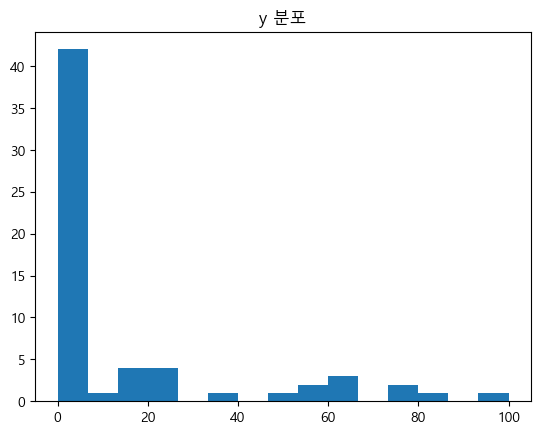

In [11]:
plt.rc('font', family='Malgun Gothic')
plt.hist(df_clean.y, bins=15)
plt.title('y 분포')
plt.show()

In [21]:
from rdkit.Chem import Descriptors
from sklearn.linear_model import LinearRegression

# 1. 분자 객체 생성
df_clean['Mol'] = df_clean['SMILES_std'].apply(Chem.MolFromSmiles)

# 2. 모든 Descriptor 계산 및 에러 방지 처리
def calc_desc(mol):
    res = {}
    for name, func in Descriptors.descList:
        try: res[name] = func(mol)
        except: res[name] = None
    return pd.Series(res)

# 결측치(계산 실패)가 하나라도 있는 Descriptor 열은 제외
desc_df = df_clean['Mol'].apply(calc_desc).dropna(axis=1)

# 3. 1개 변수 Linear Regression 훈련 및 최고 성능(Score) 탐색
y = df_clean['y'].values
best_score, best_desc = -1, ""

for desc in desc_df.columns:
    X = desc_df[[desc]].values
    score = LinearRegression().fit(X, y).score(X, y) # 전체 데이터 훈련 및 R^2 계산
    
    if score > best_score:
        best_score, best_desc = score, desc

print(f"최고 성능 Descriptor: {best_desc} (R^2 Score: {best_score:.4f})")

최고 성능 Descriptor: MinAbsEStateIndex (R^2 Score: 0.1473)


In [24]:
from sklearn.metrics import *
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np

# 0. 최고 성능 변수로 모델 학습 (에러 해결을 위해 추가된 줄)
X_best = desc_df[[best_desc]].values
best_model = LinearRegression().fit(X_best, y)

# 예측값 생성 및 분류용 이진화 (Threshold > 0)
y_pred = best_model.predict(X_best)
y_c, pred_c = (y > 0).astype(int), (y_pred > 0).astype(int)
tn, fp, fn, tp = confusion_matrix(y_c, pred_c).ravel()
rmse = np.sqrt(mean_squared_error(y, y_pred))

# 1. Regression 지표
print(f"[Regression]")
print(f"R2: {r2_score(y, y_pred):.3f} | RMSE: {rmse:.3f} | MAE: {mean_absolute_error(y, y_pred):.3f}")
print(f"nRMSE: {rmse / (y.max() - y.min()):.3f} | Spearman: {spearmanr(y, y_pred)[0]:.3f}\n")

# 2. Classification 지표
print(f"[Classification] CM:\n{confusion_matrix(y_c, pred_c)}")
print(f"Acc: {accuracy_score(y_c, pred_c):.3f} | Sens: {recall_score(y_c, pred_c, zero_division=0):.3f} | Spec: {tn/(tn+fp) if (tn+fp)>0 else 0:.3f}")
print(f"F1: {f1_score(y_c, pred_c, zero_division=0):.3f} | MCC: {matthews_corrcoef(y_c, pred_c):.3f} | AUC: {roc_auc_score(y_c, y_pred):.3f}")

[Regression]
R2: 0.147 | RMSE: 23.779 | MAE: 16.988
nRMSE: 0.238 | Spearman: 0.233

[Classification] CM:
[[ 0 30]
 [ 0 31]]
Acc: 0.508 | Sens: 1.000 | Spec: 0.000
F1: 0.674 | MCC: 0.000 | AUC: 0.580


In [25]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
from scipy.stats import spearmanr
import numpy as np

# 1. Feature Selection: y값과 연관성이 높은 상위 5개 변수만 선택
k_features = 5
selector = SelectKBest(score_func=f_regression, k=k_features)
X_multi = selector.fit_transform(desc_df, y)

selected_descs = desc_df.columns[selector.get_support()].tolist()
print(f"✅ 선택된 {k_features}개의 Descriptor: {selected_descs}\n")

# 2. 다중 선형 회귀(Multiple Linear Regression) 모델 학습 및 예측
multi_model = LinearRegression().fit(X_multi, y)
y_pred = multi_model.predict(X_multi)

# 3. 평가지표 계산
y_c, pred_c = (y > 0).astype(int), (y_pred > 0).astype(int)
tn, fp, fn, tp = confusion_matrix(y_c, pred_c).ravel()
rmse = np.sqrt(mean_squared_error(y, y_pred))

# [출력]
print(f"[다중 회귀 - Regression]")
print(f"R2: {r2_score(y, y_pred):.3f} | RMSE: {rmse:.3f} | MAE: {mean_absolute_error(y, y_pred):.3f}")
print(f"nRMSE: {rmse / (y.max() - y.min()):.3f} | Spearman: {spearmanr(y, y_pred)[0]:.3f}\n")

print(f"[다중 회귀 - Classification] CM:\n{confusion_matrix(y_c, pred_c)}")
print(f"Acc: {accuracy_score(y_c, pred_c):.3f} | Sens: {recall_score(y_c, pred_c, zero_division=0):.3f} | Spec: {tn/(tn+fp) if (tn+fp)>0 else 0:.3f}")
print(f"F1: {f1_score(y_c, pred_c, zero_division=0):.3f} | MCC: {matthews_corrcoef(y_c, pred_c):.3f} | AUC: {roc_auc_score(y_c, y_pred):.3f}")


✅ 선택된 5개의 Descriptor: ['MinAbsEStateIndex', 'Chi1', 'PEOE_VSA7', 'fr_C_O_noCOO', 'fr_ester']

[다중 회귀 - Regression]
R2: 0.261 | RMSE: 22.144 | MAE: 16.400
nRMSE: 0.221 | Spearman: 0.516

[다중 회귀 - Classification] CM:
[[ 6 24]
 [ 3 28]]
Acc: 0.557 | Sens: 0.903 | Spec: 0.200
F1: 0.675 | MCC: 0.146 | AUC: 0.728
